In [ ]:
import subprocess
import sys

def pip_install(pkgs):
    cmd = [sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir"] + pkgs
    r = subprocess.run(cmd, capture_output=True, text=True)
    if r.returncode != 0:
        print("Pip install failed:", " ".join(pkgs))
        print(r.stderr[:1200])
    return r.returncode == 0

# Base deps first (so wfdb always installs)
pip_install(["pip", "-U"])
pip_install(["wfdb", "tqdm", "scikit-learn", "seaborn", "matplotlib"])

# # Try installing mamba-ssm (optional)
# HAVE_MAMBA_SSM = False
# try:
#     import mamba_ssm  # noqa: F401

#     HAVE_MAMBA_SSM = True
# except Exception:
#     ok = pip_install(["mamba-ssm"])
#     if ok:
#         try:
#             import mamba_ssm  # noqa: F401

#             HAVE_MAMBA_SSM = True
#         except Exception:
#             HAVE_MAMBA_SSM = False

import os
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import wfdb
from tqdm.auto import tqdm

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
# print("HAVE_MAMBA_SSM:", HAVE_MAMBA_SSM)

Torch: 2.10.0+cu128
CUDA available: True


In [ ]:
DATA_DIR = Path("/content/mitdb")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Auto-download to runtime disk (no zip needed; wfdb saves files directly)
wfdb.dl_database("mitdb", dl_dir=str(DATA_DIR))

print("Downloaded to:", DATA_DIR)
print("Num files:", len(list(DATA_DIR.glob("*"))))

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [ ]:
records = sorted({p.stem for p in DATA_DIR.glob("*.dat")})
print("Num records:", len(records))
print("First 10 records:", records[:10])

# Quick verification: read one record + annotation
rid = "100" if "100" in records else records[0]
rec = wfdb.rdrecord(str(DATA_DIR / rid))
ann = wfdb.rdann(str(DATA_DIR / rid), "atr")

print("Record:", rid)
print("fs:", rec.fs)
print("sig_name:", rec.sig_name)
print("signal shape:", rec.p_signal.shape)
print("ann count:", len(ann.sample), "first symbols:", ann.symbol[:10])

Num records: 48
First 10 records: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109']
Record: 100
fs: 360
sig_name: ['MLII', 'V5']
signal shape: (650000, 2)
ann count: 2274 first symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


In [ ]:
# =========================
# 0) Repro + device
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# =========================
# 1) AAMI mapping + helpers
# =========================
AAMI_MAP = {}
for s in ["N", "L", "R", "e", "j"]:
    AAMI_MAP[s] = "N"
for s in ["A", "a", "J", "S"]:
    AAMI_MAP[s] = "S"
for s in ["V", "E"]:
    AAMI_MAP[s] = "V"
for s in ["F"]:
    AAMI_MAP[s] = "F"
for s in ["/", "f", "Q", "|"]:
    AAMI_MAP[s] = "Q"

CLASSES = ["N", "S", "V", "F", "Q"]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}


def pick_ecg_channel(rec) -> int:
    if hasattr(rec, "sig_name") and rec.sig_name:
        for i, name in enumerate(rec.sig_name):
            if str(name).upper() == "MLII":
                return i
    return 0


def load_record_signal_and_ann(record_id: str, data_dir: Path):
    rec_path = str(data_dir / record_id)
    rec = wfdb.rdrecord(rec_path)
    ann = wfdb.rdann(rec_path, "atr")

    fs = int(rec.fs)
    ch = pick_ecg_channel(rec)
    sig = rec.p_signal[:, ch].astype(np.float32)

    ann_samples = ann.sample.astype(np.int32)
    ann_symbols = ann.symbol
    return sig, fs, ann_samples, ann_symbols


# Standard inter-patient split
TRAIN_RECORDS = [
    "101",
    "106",
    "108",
    "109",
    "112",
    "114",
    "115",
    "116",
    "118",
    "119",
    "122",
    "124",
    "201",
    "203",
    "205",
    "207",
    "208",
    "209",
    "215",
    "220",
    "223",
    "230",
]
TEST_RECORDS = [
    "100",
    "103",
    "105",
    "111",
    "113",
    "117",
    "121",
    "123",
    "200",
    "202",
    "210",
    "212",
    "213",
    "214",
    "219",
    "221",
    "222",
    "228",
    "231",
    "232",
    "233",
    "234",
]

# =========================
# 2) Build beat-centered windows dataset
# =========================
from torch.utils.data import Dataset, DataLoader


class BeatWindowDataset(Dataset):
    def __init__(self, items, normalize=True):
        self.items = items
        self.normalize = normalize

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        x, y = self.items[idx]
        x = x.astype(np.float32)

        if self.normalize:
            x = (x - x.mean()) / (x.std() + 1e-6)

        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


def build_items_for_records(
    record_ids,
    data_dir,
    window_sec=1.0,
    max_beats_per_record=None,
):
    all_items = []
    fs_global = None

    for rid in record_ids:
        sig, fs, ann_samples, ann_symbols = load_record_signal_and_ann(rid, data_dir)
        if fs_global is None:
            fs_global = fs
        if fs != fs_global:
            raise ValueError("Sampling rate mismatch")

        L = int(window_sec * fs)
        if L % 2 == 1:
            L += 1
        half = L // 2

        beats = []
        for s_idx, sym in zip(ann_samples, ann_symbols):
            if sym in AAMI_MAP:
                cls = AAMI_MAP[sym]
                beats.append((int(s_idx), CLASS_TO_ID[cls]))

        if max_beats_per_record is not None and len(beats) > max_beats_per_record:
            rng = np.random.RandomState(SEED)
            idxs = rng.choice(len(beats), max_beats_per_record, replace=False)
            beats = [beats[i] for i in idxs]
            beats.sort(key=lambda t: t[0])

        added = 0
        for center, y in beats:
            start = center - half
            end = center + half
            if start < 0 or end > len(sig):
                continue
            x = sig[start:end].copy()
            if len(x) != L:
                continue
            all_items.append((x, y))
            added += 1

        print(f"{rid}: beats={len(beats)} added={added} total={len(all_items)}")

    return all_items, int(fs_global), int(L)


WINDOW_SEC = 1.0
MAX_TRAIN_BEATS_PER_REC = 2500
MAX_TEST_BEATS_PER_REC = 1200

train_items, fs, window_len = build_items_for_records(
    TRAIN_RECORDS,
    DATA_DIR,
    window_sec=WINDOW_SEC,
    max_beats_per_record=MAX_TRAIN_BEATS_PER_REC,
)
test_items, fs2, window_len2 = build_items_for_records(
    TEST_RECORDS,
    DATA_DIR,
    window_sec=WINDOW_SEC,
    max_beats_per_record=MAX_TEST_BEATS_PER_REC,
)

assert fs == fs2 and window_len == window_len2
print("fs:", fs, "window_len:", window_len)
print("train items:", len(train_items), "test items:", len(test_items))

train_ds = BeatWindowDataset(train_items, normalize=True)
test_ds = BeatWindowDataset(test_items, normalize=True)

BATCH_SIZE = 256
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

# Class weights for imbalance
train_labels = np.array([y for _, y in train_items], dtype=np.int64)
counts = np.bincount(train_labels, minlength=len(CLASSES)).astype(np.float32)
weights = (counts.sum() / (counts + 1e-6)).astype(np.float32)
weights = weights / weights.mean()
class_weights = torch.tensor(weights, device=DEVICE)
print("Class counts:", dict(zip(CLASSES, counts.astype(int))))
print("Class weights:", dict(zip(CLASSES, weights.round(3))))

# =========================
# 3) Model: use mamba-ssm if available; else fallback "Mamba-inspired" block
# =========================
# if HAVE_MAMBA_SSM:
#     from mamba_ssm import Mamba

#     class ECGMamba(nn.Module):
#         def __init__(self, d_model=128, n_layers=4, n_classes=5, k=9):
#             super().__init__()
#             self.stem = nn.Sequential(
#                 nn.Conv1d(1, d_model, kernel_size=k, padding=k // 2),
#                 nn.ReLU(),
#                 nn.Conv1d(d_model, d_model, kernel_size=k, padding=k // 2),
#             )
#             self.layers = nn.ModuleList([Mamba(d_model=d_model) for _ in range(n_layers)])
#             self.head = nn.Sequential(
#                 nn.LayerNorm(d_model),
#                 nn.Linear(d_model, n_classes),
#             )

#         def forward(self, x):
#             x = x.unsqueeze(1)  # (B,1,L)
#             x = self.stem(x)  # (B,D,L)
#             x = x.transpose(1, 2)  # (B,L,D)
#             for layer in self.layers:
#                 x = layer(x)
#             x = x.mean(dim=1)
#             return self.head(x)

# else:
    # Pure PyTorch fallback: a lightweight "Mamba-inspired" gated conv + diagonal SSM scan.
    # Not identical to official Mamba, but keeps the streaming/long-seq spirit without extra libs.
class DiagonalSSM(nn.Module):
    def __init__(self, d_model, state_mul=1):
        super().__init__()
        self.d_model = d_model
        self.state_dim = d_model * state_mul

        self.in_proj = nn.Linear(d_model, 3 * self.state_dim)
        self.out_proj = nn.Linear(self.state_dim, d_model)

        # negative diagonal dynamics (stable)
        self.A_log = nn.Parameter(torch.randn(self.state_dim) * 0.1 - 1.0)

    def forward(self, x):
        # x: (B,L,D)
        B, L, D = x.shape
        u = self.in_proj(x)  # (B,L,3*state)
        u1, u2, u3 = u.chunk(3, dim=-1)

        # dt in (0,1) range
        dt = torch.sigmoid(u1)
        inp = torch.tanh(u2)
        gate = torch.sigmoid(u3)

        A = -torch.exp(self.A_log).view(1, 1, -1)  # (1,1,state)

        # scan
        s = torch.zeros(B, self.state_dim, device=x.device, dtype=x.dtype)
        ys = []
        for t in range(L):
            a = torch.exp(A[:, 0, :] * dt[:, t, :])  # (B,state)
            s = a * s + (1.0 - a) * inp[:, t, :]
            y = gate[:, t, :] * s
            ys.append(y)

        y = torch.stack(ys, dim=1)  # (B,L,state)
        return self.out_proj(y)

class MambaLiteBlock(nn.Module):
    def __init__(self, d_model, k=9):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.dwconv = nn.Conv1d(
            d_model,
            d_model,
            kernel_size=k,
            padding=k // 2,
            groups=d_model,
        )
        self.ssm = DiagonalSSM(d_model=d_model, state_mul=1)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 2 * d_model),
            nn.GELU(),
            nn.Linear(2 * d_model, d_model),
        )

    def forward(self, x):
        # x: (B,L,D)
        h = self.norm(x)
        h = self.dwconv(h.transpose(1, 2)).transpose(1, 2)
        h = self.ssm(h)
        x = x + h
        x = x + self.mlp(self.norm(x))
        return x

class ECGMamba(nn.Module):
    def __init__(self, d_model=128, n_layers=4, n_classes=5, k=9):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, d_model, kernel_size=k, padding=k // 2),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=k, padding=k // 2),
        )
        self.layers = nn.ModuleList(
            [MambaLiteBlock(d_model=d_model, k=k) for _ in range(n_layers)]
        )
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # (B,1,L)
        x = self.stem(x)  # (B,D,L)
        x = x.transpose(1, 2)  # (B,L,D)
        for layer in self.layers:
            x = layer(x)
        x = x.mean(dim=1)
        return self.head(x)

model = ECGMamba(d_model=128, n_layers=4, n_classes=len(CLASSES)).to(DEVICE)
# print("Model ready. Using official mamba-ssm:", HAVE_MAMBA_SSM)

# =========================
# 4) Train with progress bars + accuracy
# =========================
def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=("Train" if train_mode else "Eval"), leave=False)
    for x, y in pbar:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            logits = model(x)
            loss = F.cross_entropy(logits, y, weight=class_weights)
            if train_mode:
                loss.backward()
                optimizer.step()

        bs = x.size(0)
        total_loss += float(loss.item()) * bs
        pred = logits.argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += bs

        pbar.set_postfix(
            loss=total_loss / max(total, 1),
            acc=correct / max(total, 1),
        )

    return total_loss / max(total, 1), correct / max(total, 1)


optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-2)
EPOCHS = 8

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, optimizer=optimizer)
    va_loss, va_acc = run_epoch(model, test_loader, optimizer=None)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss={tr_loss:.4f} acc={tr_acc:.4f} | "
        f"val loss={va_loss:.4f} acc={va_acc:.4f}"
    )

# =========================
# 5) Save model for reuse
# =========================
CKPT_PATH = "/content/ecg_mamba_mitbih_aami.pt"
ckpt = {
    "model_state": model.state_dict(),
    "config": {
        "window_sec": WINDOW_SEC,
        "fs": fs,
        "window_len": window_len,
        "classes": CLASSES,
        "have_mamba_ssm": HAVE_MAMBA_SSM,
    },
    "seed": SEED,
}
torch.save(ckpt, CKPT_PATH)
print("Saved checkpoint:", CKPT_PATH)

# =========================
# 6) Evaluation: confusion matrix + report
# =========================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def predict_all(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Predict", leave=False):
            x = x.to(DEVICE, non_blocking=True)
            logits = model(x)
            pred = logits.argmax(dim=1).cpu().numpy()
            ys.append(y.numpy())
            ps.append(pred)
    return np.concatenate(ys), np.concatenate(ps)

y_true, y_pred = predict_all(model, test_loader)

print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASSES))))
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

plt.figure(figsize=(6.4, 5.2))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
)
plt.title("Confusion Matrix (Normalized) - Test")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train")
plt.plot(history["val_acc"], label="val")
plt.title("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Sample window plots
def plot_sample_windows(model, dataset, n=6):
    model.eval()
    rng = np.random.RandomState(SEED)
    idxs = rng.choice(len(dataset), size=n, replace=False)

    plt.figure(figsize=(12, 2.1 * n))
    with torch.no_grad():
        for i, idx in enumerate(idxs, start=1):
            x, y = dataset[idx]
            logits = model(x.unsqueeze(0).to(DEVICE))
            p = int(logits.argmax(dim=1).item())

            ax = plt.subplot(n, 1, i)
            ax.plot(x.numpy(), color="black", linewidth=1.0)
            ax.set_title(
                f"Idx {idx} | True: {ID_TO_CLASS[int(y.item())]} "
                f"Pred: {ID_TO_CLASS[p]}",
                fontsize=11,
            )
            ax.set_xlim(0, len(x))
            ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

plot_sample_windows(model, test_ds, n=6)

# =========================
# 7) Real-time monitor-like demo (stream a record; predict at annotated beats)
# =========================
import time
from IPython.display import clear_output, display

@torch.no_grad()
def realtime_monitor_demo(
    model,
    record_id="100",
    seconds_on_screen=6.0,
    step_sec=0.05,
    window_sec=1.0,
):
    model.eval()
    model.to(DEVICE)

    sig, fs_local, ann_samples, ann_symbols = load_record_signal_and_ann(
        record_id,
        DATA_DIR,
    )

    L = int(window_sec * fs_local)
    if L % 2 == 1:
        L += 1
    half = L // 2

    beats = []
    for s_idx, sym in zip(ann_samples, ann_symbols):
        if sym in AAMI_MAP:
            beats.append((int(s_idx), AAMI_MAP[sym]))
    beats.sort(key=lambda t: t[0])

    screen_len = int(seconds_on_screen * fs_local)
    step_len = max(1, int(step_sec * fs_local))
    buf = np.zeros(screen_len, dtype=np.float32)

    beat_ptr = 0
    last_true = None
    last_pred = None
    last_beat_in_buf = None

    fig, ax = plt.subplots(figsize=(12, 2.6))

    for t in range(0, len(sig) - step_len, step_len):
        new = sig[t : t + step_len]
        buf = np.roll(buf, -step_len)
        buf[-step_len:] = new

        while beat_ptr < len(beats) and beats[beat_ptr][0] <= t:
            center, true_cls = beats[beat_ptr]
            start = center - half
            end = center + half
            if start >= 0 and end <= len(sig):
                x = sig[start:end].astype(np.float32)
                x = (x - x.mean()) / (x.std() + 1e-6)
                x_t = torch.from_numpy(x).unsqueeze(0).to(DEVICE)
                logits = model(x_t)
                pred_id = int(logits.argmax(dim=1).item())
                pred_cls = ID_TO_CLASS[pred_id]

                last_true = true_cls
                last_pred = pred_cls

                rel = center - t
                pos = int(np.clip(screen_len + rel, 0, screen_len - 1))
                last_beat_in_buf = pos

            beat_ptr += 1

        ax.clear()
        ax.set_facecolor("black")
        fig.patch.set_facecolor("black")

        ax.plot(buf, color="lime", linewidth=1.0)
        ax.set_xlim(0, screen_len)
        ax.set_ylim(-2.5, 2.5)

        if last_beat_in_buf is not None:
            ax.axvline(last_beat_in_buf, color="yellow", linewidth=1.0, alpha=0.9)

        title = f"MIT-BIH {record_id} | Live Beat Class  "
        if last_pred is None:
            title += "| waiting for beats..."
        else:
            title += f"| True: {last_true}  Pred: {last_pred}"
        ax.set_title(title, color="white", fontsize=12)

        ax.tick_params(colors="white")
        for spine in ax.spines.values():
            spine.set_color("white")

        clear_output(wait=True)
        display(fig)
        time.sleep(0.03)

    plt.close(fig)

realtime_monitor_demo(model, record_id="100")

DEVICE: cuda
101: beats=1869 added=1868 total=1868
106: beats=2027 added=2027 total=3895
108: beats=1771 added=1770 total=5665
109: beats=2500 added=2498 total=8163
112: beats=2500 added=2498 total=10661
114: beats=1880 added=1880 total=12541
115: beats=1959 added=1957 total=14498
116: beats=2412 added=2411 total=16909
118: beats=2278 added=2277 total=19186
119: beats=1987 added=1987 total=21173
122: beats=2478 added=2476 total=23649
124: beats=1619 added=1618 total=25267
201: beats=1963 added=1962 total=27229
203: beats=2500 added=2499 total=29728
205: beats=2500 added=2499 total=32227
207: beats=1862 added=1861 total=34088
208: beats=2500 added=2498 total=36586
209: beats=2500 added=2499 total=39085
215: beats=2500 added=2498 total=41583
220: beats=2048 added=2046 total=43629
223: beats=2500 added=2499 total=46128
230: beats=2257 added=2256 total=48384
100: beats=1200 added=1200 total=1200
103: beats=1200 added=1200 total=2400
105: beats=1200 added=1200 total=3600
111: beats=1200 add

Train:   0%|          | 0/189 [00:00<?, ?it/s]

KeyboardInterrupt: 

DEVICE: cuda
101: beats=800 added=800
106: beats=800 added=800
108: beats=800 added=800
109: beats=800 added=799
112: beats=800 added=799
114: beats=800 added=800
115: beats=800 added=800
116: beats=800 added=800
118: beats=800 added=800
119: beats=800 added=800
122: beats=800 added=799
124: beats=800 added=800
201: beats=800 added=800
203: beats=800 added=799
205: beats=800 added=799
207: beats=800 added=800
208: beats=800 added=799
209: beats=800 added=799
215: beats=800 added=799
220: beats=800 added=800
223: beats=800 added=799
230: beats=800 added=800
100: beats=300 added=300
103: beats=300 added=300
105: beats=300 added=300
111: beats=300 added=300
113: beats=300 added=300
117: beats=300 added=300
121: beats=300 added=300
123: beats=300 added=300
200: beats=300 added=300
202: beats=300 added=300
210: beats=300 added=300
212: beats=300 added=300
213: beats=300 added=299
214: beats=300 added=300
219: beats=300 added=300
221: beats=300 added=300
222: beats=300 added=299
228: beats=3

/tmp/ipython-input-794/3307876596.py:366: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


Train:   0%|          | 0/17 [00:00<?, ?it/s]

W0228 07:22:40.642000 794 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Eval:   0%|          | 0/7 [00:00<?, ?it/s]

...

Train:   0%|          | 0/17 [00:00<?, ?it/s]

Eval:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 10/10 | train loss=1.2356 acc=0.5003 | val loss=1.3803 acc=0.3722
Saved checkpoint: /content/ecg_mambalite_mitbih_aami.pt


Predict:   0%|          | 0/7 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           N     0.9941    0.3442    0.5113      5884
           S     0.1297    0.6490    0.2162       302
           V     0.4538    0.6260    0.5262       369
           F     0.0010    0.0270    0.0019        37
           Q     0.0013    0.5000    0.0026         4

    accuracy                         0.3722      6596
   macro avg     0.3160    0.4292    0.2516      6596
weighted avg     0.9181    0.3722    0.4955      6596



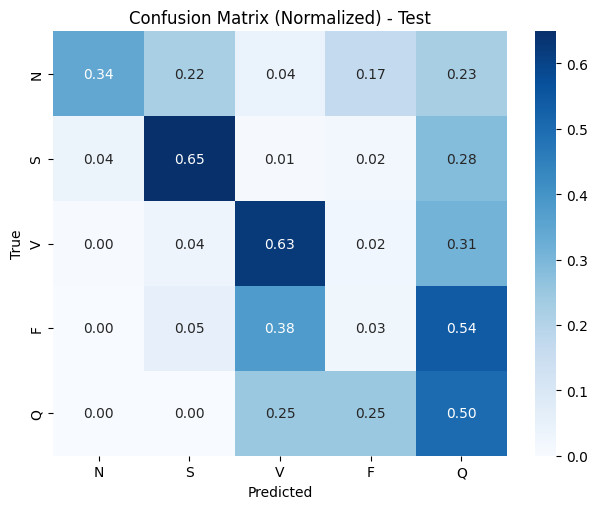

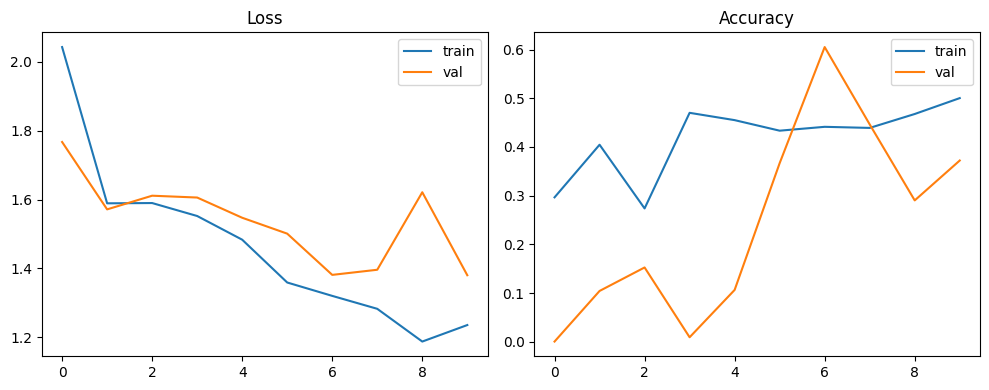

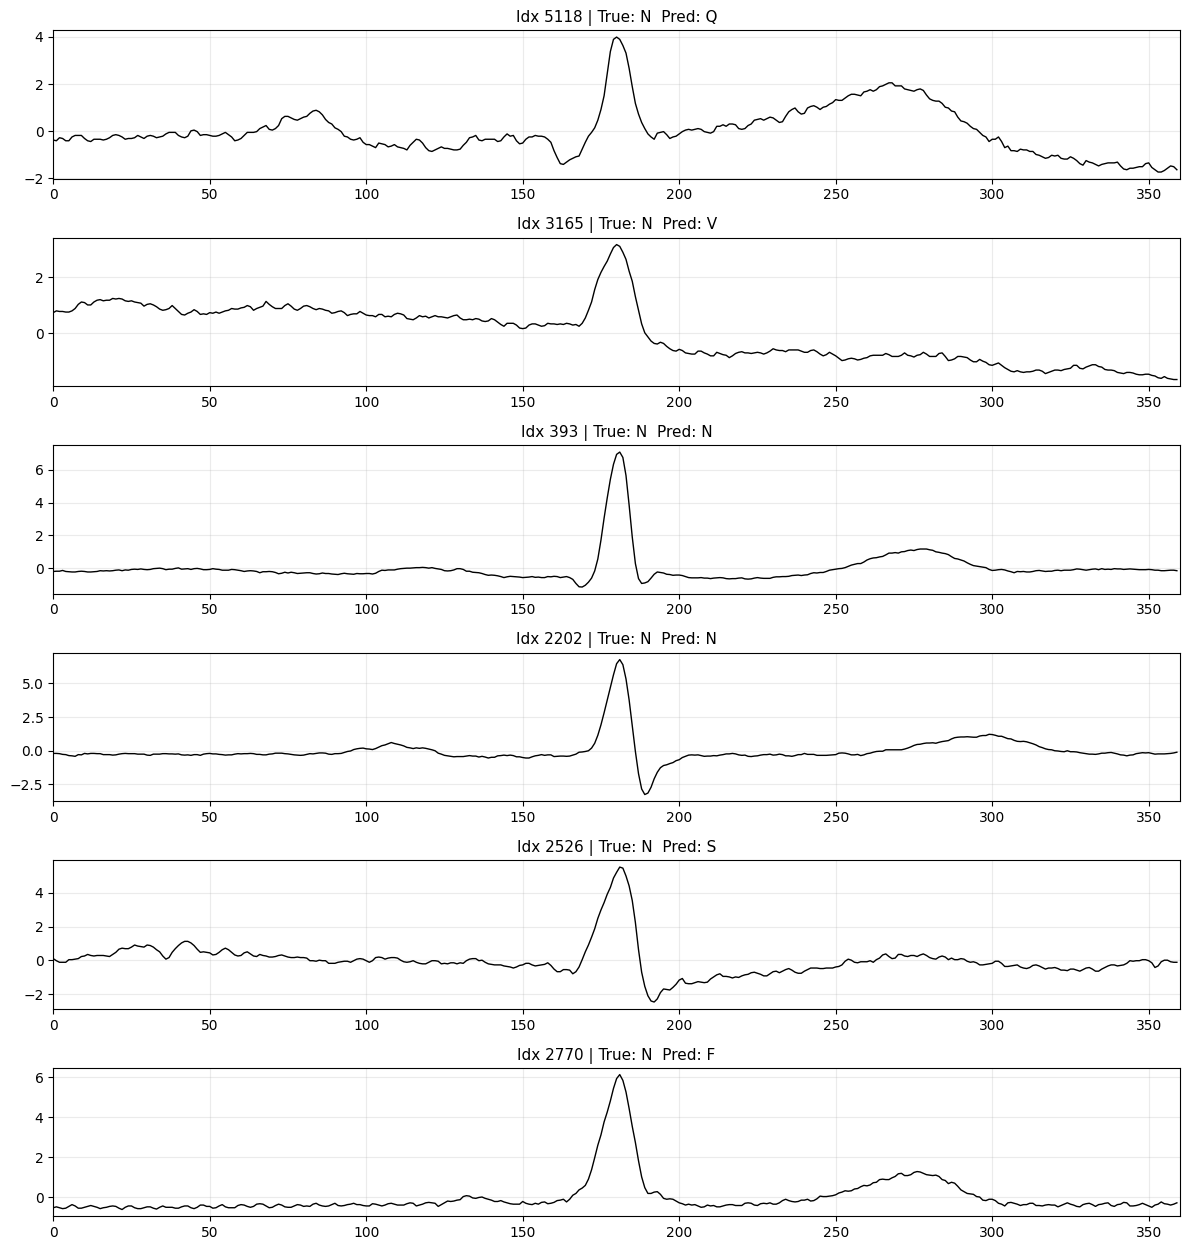

In [ ]:
# =========================
# CELL 4 (REPLACE YOUR OLD CELL 4 WITH THIS)
# Fast pure-PyTorch "Mamba-style" model (NO mamba-ssm),
# faster dataset pipeline, AMP, bigger batch, GPU-friendly settings,
# training + save + eval + confusion matrix + sample plots + realtime monitor demo.
# =========================

import time
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import clear_output, display

# ---------- 0) Repro / GPU knobs ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

# ---------- 1) AAMI mapping ----------
AAMI_MAP = {}
for s in ["N", "L", "R", "e", "j"]:
    AAMI_MAP[s] = "N"
for s in ["A", "a", "J", "S"]:
    AAMI_MAP[s] = "S"
for s in ["V", "E"]:
    AAMI_MAP[s] = "V"
for s in ["F"]:
    AAMI_MAP[s] = "F"
for s in ["/", "f", "Q", "|"]:
    AAMI_MAP[s] = "Q"

CLASSES = ["N", "S", "V", "F", "Q"]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}


def pick_ecg_channel(rec) -> int:
    # Prefer MLII when present
    if hasattr(rec, "sig_name") and rec.sig_name:
        for i, name in enumerate(rec.sig_name):
            if str(name).upper() == "MLII":
                return i
    return 0


def load_record_signal_and_ann(record_id: str, data_dir: Path):
    import wfdb  # uses installed wfdb from previous cells

    rec_path = str(data_dir / record_id)
    rec = wfdb.rdrecord(rec_path)
    ann = wfdb.rdann(rec_path, "atr")

    fs = int(rec.fs)
    ch = pick_ecg_channel(rec)
    sig = rec.p_signal[:, ch].astype(np.float32)

    ann_samples = ann.sample.astype(np.int32)
    ann_symbols = ann.symbol
    return sig, fs, ann_samples, ann_symbols


# ---------- 2) Split ----------
TRAIN_RECORDS = [
    "101",
    "106",
    "108",
    "109",
    "112",
    "114",
    "115",
    "116",
    "118",
    "119",
    "122",
    "124",
    "201",
    "203",
    "205",
    "207",
    "208",
    "209",
    "215",
    "220",
    "223",
    "230",
]
TEST_RECORDS = [
    "100",
    "103",
    "105",
    "111",
    "113",
    "117",
    "121",
    "123",
    "200",
    "202",
    "210",
    "212",
    "213",
    "214",
    "219",
    "221",
    "222",
    "228",
    "231",
    "232",
    "233",
    "234",
]

# ---------- 3) FAST MODE settings (tune these) ----------
# Biggest time saver: fewer windows.
WINDOW_SEC = 1.0
MAX_TRAIN_BEATS_PER_REC = 800  # try 500 if still slow
MAX_TEST_BEATS_PER_REC = 300

# Bigger batch -> more GPU use (increase until near memory limit)
BATCH_SIZE = 1024  # try 2048 on T4; if OOM drop to 512

EPOCHS = 10  # start 3; later 5-10

# Model size knobs (bigger => more GPU use, slower)
D_MODEL = 96
N_LAYERS = 4
KERNEL = 9
EXPANSION = 2

DATA_DIR = Path("/content/mitdb")

# ---------- 4) Build beat-centered windows (normalize ONCE here) ----------
class BeatWindowDataset(Dataset):
    def __init__(self, xs: np.ndarray, ys: np.ndarray):
        # xs: (N, L) float32, already normalized
        # ys: (N,) int64
        self.xs = xs
        self.ys = ys

    def __len__(self):
        return int(self.xs.shape[0])

    def __getitem__(self, idx):
        return torch.from_numpy(self.xs[idx]), torch.tensor(
            int(self.ys[idx]),
            dtype=torch.long,
        )


def build_items_for_records(
    record_ids,
    data_dir,
    window_sec=1.0,
    max_beats_per_record=None,
):
    xs_list = []
    ys_list = []
    fs_global = None
    window_len_global = None

    for rid in record_ids:
        sig, fs, ann_samples, ann_symbols = load_record_signal_and_ann(rid, data_dir)
        if fs_global is None:
            fs_global = fs
        if fs != fs_global:
            raise ValueError("Sampling rate mismatch")

        L = int(window_sec * fs)
        if L % 2 == 1:
            L += 1
        half = L // 2
        if window_len_global is None:
            window_len_global = L

        # collect beats mapping to AAMI
        beats = []
        for s_idx, sym in zip(ann_samples, ann_symbols):
            if sym in AAMI_MAP:
                beats.append((int(s_idx), CLASS_TO_ID[AAMI_MAP[sym]]))

        if max_beats_per_record is not None and len(beats) > max_beats_per_record:
            rng = np.random.RandomState(SEED)
            idxs = rng.choice(len(beats), max_beats_per_record, replace=False)
            beats = [beats[i] for i in idxs]
            beats.sort(key=lambda t: t[0])

        added = 0
        for center, y in beats:
            start = center - half
            end = center + half
            if start < 0 or end > len(sig):
                continue
            x = sig[start:end].astype(np.float32, copy=True)
            if x.shape[0] != L:
                continue
            # normalize once (saves lots of time later)
            x = (x - x.mean()) / (x.std() + 1e-6)

            xs_list.append(x)
            ys_list.append(y)
            added += 1

        print(f"{rid}: beats={len(beats)} added={added}")

    xs = np.stack(xs_list).astype(np.float32)
    ys = np.array(ys_list, dtype=np.int64)
    return xs, ys, int(fs_global), int(window_len_global)


train_x, train_y, fs, window_len = build_items_for_records(
    TRAIN_RECORDS,
    DATA_DIR,
    window_sec=WINDOW_SEC,
    max_beats_per_record=MAX_TRAIN_BEATS_PER_REC,
)
test_x, test_y, fs2, window_len2 = build_items_for_records(
    TEST_RECORDS,
    DATA_DIR,
    window_sec=WINDOW_SEC,
    max_beats_per_record=MAX_TEST_BEATS_PER_REC,
)
assert fs == fs2 and window_len == window_len2
print("fs:", fs, "window_len:", window_len)
print("Train:", train_x.shape, train_y.shape, "Test:", test_x.shape, test_y.shape)

train_ds = BeatWindowDataset(train_x, train_y)
test_ds = BeatWindowDataset(test_x, test_y)

# Fix your DataLoader multiprocessing assertion by using num_workers=0 in Colab/Py3.12
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

# Class weights (imbalance)
counts = np.bincount(train_y, minlength=len(CLASSES)).astype(np.float32)
weights = (counts.sum() / (counts + 1e-6)).astype(np.float32)
weights = weights / weights.mean()
class_weights = torch.tensor(weights, device=DEVICE)
print("Class counts:", dict(zip(CLASSES, counts.astype(int))))
print("Class weights:", dict(zip(CLASSES, weights.round(3))))

# ---------- 5) Fast "Mamba-style" model (no scan loop) ----------
class MambaLiteBlock(nn.Module):
    """
    Fast, GPU-friendly temporal mixing:
    - LayerNorm
    - linear expand -> (u, v)
    - depthwise conv on u (temporal)
    - gated activation silu(u_conv) * sigmoid(v)
    - project back + residual
    """

    def __init__(self, d_model, k=9, expansion=2):
        super().__init__()
        inner = expansion * d_model
        self.norm = nn.LayerNorm(d_model)
        self.in_proj = nn.Linear(d_model, 2 * inner)
        self.dwconv = nn.Conv1d(
            inner,
            inner,
            kernel_size=k,
            padding=k // 2,
            groups=inner,
        )
        self.out_proj = nn.Linear(inner, d_model)

    def forward(self, x):
        # x: (B, L, D)
        h = self.norm(x)
        u, v = self.in_proj(h).chunk(2, dim=-1)  # (B, L, inner)
        u = self.dwconv(u.transpose(1, 2)).transpose(1, 2)
        h = F.silu(u) * torch.sigmoid(v)
        return x + self.out_proj(h)


class ECGMambaLite(nn.Module):
    def __init__(self, d_model=96, n_layers=4, n_classes=5, k=9, expansion=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, d_model, kernel_size=k, padding=k // 2),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=k, padding=k // 2),
        )
        self.layers = nn.ModuleList(
            [
                MambaLiteBlock(
                    d_model=d_model,
                    k=k,
                    expansion=expansion,
                )
                for _ in range(n_layers)
            ]
        )
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, n_classes),
        )

    def forward(self, x):
        # x: (B, L)
        x = x.unsqueeze(1)  # (B, 1, L)
        x = self.stem(x)  # (B, D, L)
        x = x.transpose(1, 2)  # (B, L, D)
        for layer in self.layers:
            x = layer(x)
        x = x.mean(dim=1)  # global average pooling
        return self.head(x)


model = ECGMambaLite(
    d_model=D_MODEL,
    n_layers=N_LAYERS,
    n_classes=len(CLASSES),
    k=KERNEL,
    expansion=EXPANSION,
).to(DEVICE)

# Optional compile (can speed up, but first step takes time)
if hasattr(torch, "compile"):
    try:
        model = torch.compile(model)
        print("torch.compile enabled")
    except Exception as e:
        print("torch.compile failed (continuing without):", str(e)[:200])

print(model)

# ---------- 6) Training (AMP to use GPU more) ----------
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-2)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=("Train" if train_mode else "Eval"), leave=False)
    for x, y in pbar:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(DEVICE == "cuda"),
            ):
                logits = model(x)
                loss = F.cross_entropy(logits, y, weight=class_weights)

            if train_mode:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        bs = x.size(0)
        total_loss += float(loss.item()) * bs
        pred = logits.argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += bs

        pbar.set_postfix(loss=total_loss / max(total, 1), acc=correct / max(total, 1))

    return total_loss / max(total, 1), correct / max(total, 1)


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, optimizer=optimizer)
    va_loss, va_acc = run_epoch(model, test_loader, optimizer=None)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss={tr_loss:.4f} acc={tr_acc:.4f} | "
        f"val loss={va_loss:.4f} acc={va_acc:.4f}"
    )

# ---------- 7) Save ----------
CKPT_PATH = "/content/ecg_mambalite_mitbih_aami.pt"
torch.save(
    {
        "model_state": model.state_dict(),
        "config": {
            "window_sec": WINDOW_SEC,
            "fs": fs,
            "window_len": window_len,
            "classes": CLASSES,
            "d_model": D_MODEL,
            "n_layers": N_LAYERS,
            "kernel": KERNEL,
            "expansion": EXPANSION,
        },
        "seed": SEED,
    },
    CKPT_PATH,
)
print("Saved checkpoint:", CKPT_PATH)

# ---------- 8) Eval: report + confusion ----------
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    ys, ps = [], []
    for x, y in tqdm(loader, desc="Predict", leave=False):
        x = x.to(DEVICE, non_blocking=True)
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE == "cuda"),
        ):
            logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        ys.append(y.numpy())
        ps.append(pred)
    return np.concatenate(ys), np.concatenate(ps)


y_true, y_pred = predict_all(model, test_loader)
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASSES))))
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

plt.figure(figsize=(6.4, 5.2))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
)
plt.title("Confusion Matrix (Normalized) - Test")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train")
plt.plot(history["val_acc"], label="val")
plt.title("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# ---------- 9) Sample window visualization ----------
@torch.no_grad()
def plot_sample_windows(model, xs, ys, n=6):
    model.eval()
    rng = np.random.RandomState(SEED)
    idxs = rng.choice(len(xs), size=min(n, len(xs)), replace=False)

    plt.figure(figsize=(12, 2.1 * len(idxs)))
    for i, idx in enumerate(idxs, start=1):
        x = torch.from_numpy(xs[idx]).unsqueeze(0).to(DEVICE)
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE == "cuda"),
        ):
            logits = model(x)
        p = int(logits.argmax(dim=1).item())

        ax = plt.subplot(len(idxs), 1, i)
        ax.plot(xs[idx], color="black", linewidth=1.0)
        ax.set_title(
            f"Idx {idx} | True: {ID_TO_CLASS[int(ys[idx])]}  Pred: {ID_TO_CLASS[p]}",
            fontsize=11,
        )
        ax.set_xlim(0, xs.shape[1])
        ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


plot_sample_windows(model, test_x, test_y, n=6)



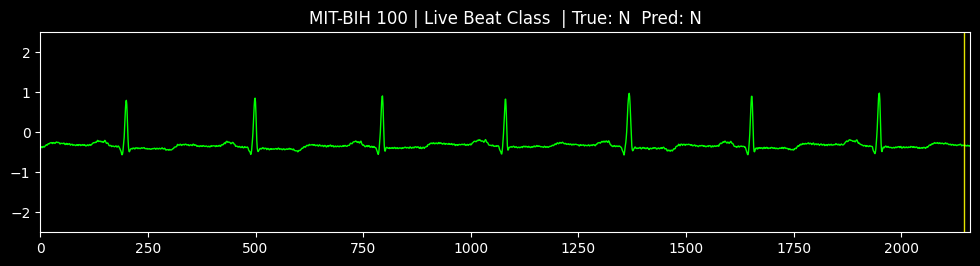

KeyboardInterrupt: 

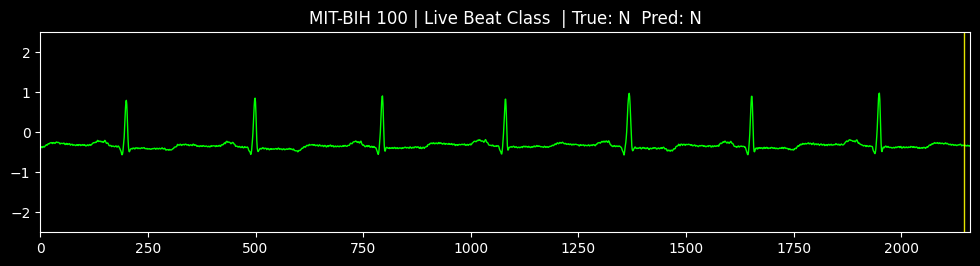

In [ ]:
# ---------- 10) Real-time monitor demo ----------
@torch.no_grad()
def realtime_monitor_demo(
    model,
    record_id="100",
    seconds_on_screen=6.0,
    step_sec=0.05,
    window_sec=1.0,
):
    model.eval()
    model.to(DEVICE)

    sig, fs_local, ann_samples, ann_symbols = load_record_signal_and_ann(
        record_id,
        DATA_DIR,
    )

    L = int(window_sec * fs_local)
    if L % 2 == 1:
        L += 1
    half = L // 2

    beats = []
    for s_idx, sym in zip(ann_samples, ann_symbols):
        if sym in AAMI_MAP:
            beats.append((int(s_idx), AAMI_MAP[sym]))
    beats.sort(key=lambda t: t[0])

    screen_len = int(seconds_on_screen * fs_local)
    step_len = max(1, int(step_sec * fs_local))
    buf = np.zeros(screen_len, dtype=np.float32)

    beat_ptr = 0
    last_true = None
    last_pred = None
    last_beat_in_buf = None

    fig, ax = plt.subplots(figsize=(12, 2.6))

    for t in range(0, len(sig) - step_len, step_len):
        new = sig[t : t + step_len]
        buf = np.roll(buf, -step_len)
        buf[-step_len:] = new

        while beat_ptr < len(beats) and beats[beat_ptr][0] <= t:
            center, true_cls = beats[beat_ptr]
            start = center - half
            end = center + half
            if start >= 0 and end <= len(sig):
                x = sig[start:end].astype(np.float32)
                x = (x - x.mean()) / (x.std() + 1e-6)
                x_t = torch.from_numpy(x).unsqueeze(0).to(DEVICE)

                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16,
                    enabled=(DEVICE == "cuda"),
                ):
                    logits = model(x_t)
                pred_id = int(logits.argmax(dim=1).item())
                pred_cls = ID_TO_CLASS[pred_id]

                last_true = true_cls
                last_pred = pred_cls

                rel = center - t
                pos = int(np.clip(screen_len + rel, 0, screen_len - 1))
                last_beat_in_buf = pos

            beat_ptr += 1

        ax.clear()
        ax.set_facecolor("black")
        fig.patch.set_facecolor("black")
        ax.plot(buf, color="lime", linewidth=1.0)
        ax.set_xlim(0, screen_len)
        ax.set_ylim(-2.5, 2.5)

        if last_beat_in_buf is not None:
            ax.axvline(last_beat_in_buf, color="yellow", linewidth=1.0, alpha=0.9)

        title = f"MIT-BIH {record_id} | Live Beat Class  "
        if last_pred is None:
            title += "| waiting for beats..."
        else:
            title += f"| True: {last_true}  Pred: {last_pred}"
        ax.set_title(title, color="white", fontsize=12)

        ax.tick_params(colors="white")
        for spine in ax.spines.values():
            spine.set_color("white")

        clear_output(wait=True)
        display(fig)
        time.sleep(0.03)

    plt.close(fig)


realtime_monitor_demo(model, record_id="100")

# Quick GPU info (memory use is not the same as utilization, but helps debugging)
if DEVICE == "cuda":
    print(
        "Max GPU memory allocated (GB):",
        torch.cuda.max_memory_allocated() / (1024**3),
    )

DEVICE: cuda
101: beats=800 added=800
106: beats=800 added=800
108: beats=800 added=800
109: beats=800 added=799
112: beats=800 added=799
114: beats=800 added=800
115: beats=800 added=800
116: beats=800 added=800
118: beats=800 added=800
119: beats=800 added=800
122: beats=800 added=799
124: beats=800 added=800
201: beats=800 added=800
203: beats=800 added=799
205: beats=800 added=799
207: beats=800 added=800
208: beats=800 added=799
209: beats=800 added=799
215: beats=800 added=799
220: beats=800 added=800
223: beats=800 added=799
230: beats=800 added=800
100: beats=300 added=300
103: beats=300 added=300
105: beats=300 added=300
111: beats=300 added=300
113: beats=300 added=300
117: beats=300 added=300
121: beats=300 added=300
123: beats=300 added=300
200: beats=300 added=300
202: beats=300 added=300
210: beats=300 added=300
212: beats=300 added=300
213: beats=300 added=299
214: beats=300 added=300
219: beats=300 added=300
221: beats=300 added=300
222: beats=300 added=299
228: beats=3

/tmp/ipython-input-794/2486162038.py:392: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))
/tmp/ipython-input-794/2486162038.py:330: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


cnn Train e1:   0%|          | 0/17 [00:00<?, ?it/s]

cnn | epoch 01 train_acc=0.0175 val_acc=0.0458 val_macro_f1=0.0175 val_bal_acc=0.2000


cnn Train e2:   0%|          | 0/17 [00:00<?, ?it/s]

...

mambalite Train e4:   0%|          | 0/17 [00:00<?, ?it/s]

mambalite | epoch 04 train_acc=0.3488 val_acc=0.1078 val_macro_f1=0.0899 val_bal_acc=0.1782


mambalite Train e5:   0%|          | 0/17 [00:00<?, ?it/s]

mambalite | epoch 05 train_acc=0.3376 val_acc=0.7899 val_macro_f1=0.1921 val_bal_acc=0.1937
Saved: /content/mitbih_mambalite_aami5.pt
              precision    recall  f1-score   support

           N     0.8882    0.8821    0.8851      5884
           S     0.0516    0.0430    0.0469       302
           V     0.0400    0.0163    0.0231       369
           F     0.0028    0.0270    0.0052        37
           Q     0.0000    0.0000    0.0000         4

    accuracy                         0.7899      6596
   macro avg     0.1965    0.1937    0.1921      6596
weighted avg     0.7970    0.7899    0.7931      6596


=== Summary (MIT-BIH AAMI-5) ===
gru          params=0.280M acc=0.6380 macro_f1=0.2575 bal_acc=0.3411
cnn          params=0.583M acc=0.3795 macro_f1=0.2033 bal_acc=0.3069
mambalite    params=0.316M acc=0.7899 macro_f1=0.1921 bal_acc=0.1937
transformer  params=0.448M acc=0.3285 macro_f1=0.1238 bal_acc=0.2983


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


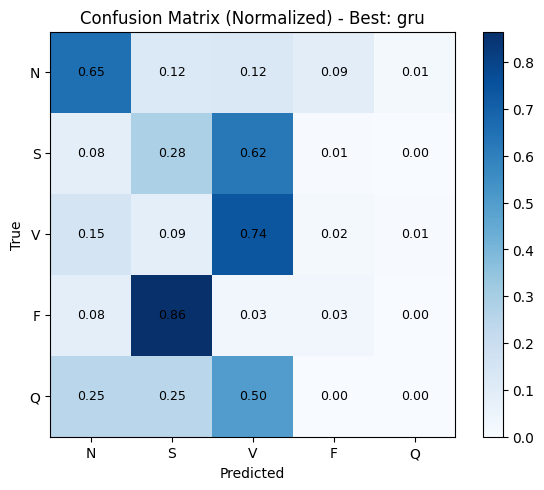

In [ ]:
# =========================
# CELL 4: MIT-BIH (AAMI-5) multi-model benchmark (pure PyTorch)
# CNN vs GRU vs Transformer vs MambaLite
# =========================

import os
import time
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    balanced_accuracy_score,
)

# ---------- Repro / device ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

DATA_DIR = Path("/content/mitdb")

# ---------- AAMI mapping ----------
AAMI_MAP = {}
for s in ["N", "L", "R", "e", "j"]:
    AAMI_MAP[s] = "N"
for s in ["A", "a", "J", "S"]:
    AAMI_MAP[s] = "S"
for s in ["V", "E"]:
    AAMI_MAP[s] = "V"
for s in ["F"]:
    AAMI_MAP[s] = "F"
for s in ["/", "f", "Q", "|"]:
    AAMI_MAP[s] = "Q"

CLASSES = ["N", "S", "V", "F", "Q"]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}

# ---------- Split (inter-patient style) ----------
TRAIN_RECORDS = [
    "101",
    "106",
    "108",
    "109",
    "112",
    "114",
    "115",
    "116",
    "118",
    "119",
    "122",
    "124",
    "201",
    "203",
    "205",
    "207",
    "208",
    "209",
    "215",
    "220",
    "223",
    "230",
]
TEST_RECORDS = [
    "100",
    "103",
    "105",
    "111",
    "113",
    "117",
    "121",
    "123",
    "200",
    "202",
    "210",
    "212",
    "213",
    "214",
    "219",
    "221",
    "222",
    "228",
    "231",
    "232",
    "233",
    "234",
]

# ---------- WFDB helpers ----------
def pick_ecg_channel(rec) -> int:
    if hasattr(rec, "sig_name") and rec.sig_name:
        for i, name in enumerate(rec.sig_name):
            if str(name).upper() == "MLII":
                return i
    return 0


def load_record_signal_and_ann(record_id: str, data_dir: Path):
    import wfdb

    rec_path = str(data_dir / record_id)
    rec = wfdb.rdrecord(rec_path)
    ann = wfdb.rdann(rec_path, "atr")

    fs = int(rec.fs)
    ch = pick_ecg_channel(rec)
    sig = rec.p_signal[:, ch].astype(np.float32)

    ann_samples = ann.sample.astype(np.int32)
    ann_symbols = ann.symbol
    return sig, fs, ann_samples, ann_symbols


# ---------- Dataset building (fast) ----------
class BeatWindowDataset(Dataset):
    def __init__(self, xs: np.ndarray, ys: np.ndarray):
        self.xs = xs.astype(np.float32)
        self.ys = ys.astype(np.int64)

    def __len__(self):
        return int(self.xs.shape[0])

    def __getitem__(self, idx):
        return torch.from_numpy(self.xs[idx]), torch.tensor(
            int(self.ys[idx]),
            dtype=torch.long,
        )


def build_windows(
    record_ids: List[str],
    window_sec: float,
    max_beats_per_record: int | None,
    data_dir: Path,
) -> Tuple[np.ndarray, np.ndarray, int, int]:
    xs_list = []
    ys_list = []
    fs_global = None
    win_len_global = None

    for rid in record_ids:
        sig, fs, ann_samples, ann_symbols = load_record_signal_and_ann(rid, data_dir)
        if fs_global is None:
            fs_global = fs
        if fs != fs_global:
            raise ValueError("Sampling rate mismatch across records")

        win_len = int(window_sec * fs)
        if win_len % 2 == 1:
            win_len += 1
        half = win_len // 2
        if win_len_global is None:
            win_len_global = win_len

        beats = []
        for s_idx, sym in zip(ann_samples, ann_symbols):
            if sym in AAMI_MAP:
                beats.append((int(s_idx), CLASS_TO_ID[AAMI_MAP[sym]]))

        if max_beats_per_record is not None and len(beats) > max_beats_per_record:
            rng = np.random.RandomState(SEED)
            idxs = rng.choice(len(beats), max_beats_per_record, replace=False)
            beats = [beats[i] for i in idxs]
            beats.sort(key=lambda t: t[0])

        added = 0
        for center, y in beats:
            start = center - half
            end = center + half
            if start < 0 or end > len(sig):
                continue
            x = sig[start:end].astype(np.float32, copy=True)
            if x.shape[0] != win_len:
                continue
            # normalize once per window
            x = (x - x.mean()) / (x.std() + 1e-6)
            xs_list.append(x)
            ys_list.append(y)
            added += 1

        print(f"{rid}: beats={len(beats)} added={added}")

    xs = np.stack(xs_list).astype(np.float32)
    ys = np.array(ys_list, dtype=np.int64)
    return xs, ys, int(fs_global), int(win_len_global)


# ---------- Experiment config ----------
WINDOW_SEC = 1.0
MAX_TRAIN_BEATS_PER_REC = 800  # reduce to 300-500 for faster iteration
MAX_TEST_BEATS_PER_REC = 300

BATCH_SIZE = 1024  # if OOM -> 512
EPOCHS = 5  # start 3 for speed; 5-10 for final runs
LR = 2e-3

train_x, train_y, fs, win_len = build_windows(
    TRAIN_RECORDS,
    window_sec=WINDOW_SEC,
    max_beats_per_record=MAX_TRAIN_BEATS_PER_REC,
    data_dir=DATA_DIR,
)
test_x, test_y, fs2, win_len2 = build_windows(
    TEST_RECORDS,
    window_sec=WINDOW_SEC,
    max_beats_per_record=MAX_TEST_BEATS_PER_REC,
    data_dir=DATA_DIR,
)
assert fs == fs2 and win_len == win_len2
print("fs:", fs, "win_len:", win_len)
print("Train:", train_x.shape, "Test:", test_x.shape)

train_ds = BeatWindowDataset(train_x, train_y)
test_ds = BeatWindowDataset(test_x, test_y)

# Colab multiprocessing can be flaky on Py3.12 -> use num_workers=0
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

# class weights (imbalance)
counts = np.bincount(train_y, minlength=len(CLASSES)).astype(np.float32)
weights = (counts.sum() / (counts + 1e-6)).astype(np.float32)
weights = weights / weights.mean()
class_weights = torch.tensor(weights, device=DEVICE)
print("Class counts:", dict(zip(CLASSES, counts.astype(int))))
print("Class weights:", dict(zip(CLASSES, weights.round(3))))


# ---------- Models (pure PyTorch), comparable size ----------
class CNN1D(nn.Module):
    def __init__(self, n_classes=5, width=96):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, width, 9, padding=4),
            nn.ReLU(),
            nn.Conv1d(width, width, 9, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(width, 2 * width, 9, padding=4),
            nn.ReLU(),
            nn.Conv1d(2 * width, 2 * width, 9, padding=4),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(2 * width, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)  # (B,1,L)
        x = self.net(x).squeeze(-1)  # (B,2W)
        return self.fc(x)


class GRUClassifier(nn.Module):
    def __init__(self, n_classes=5, d_model=96, n_layers=2, bidir=True):
        super().__init__()
        self.in_proj = nn.Linear(1, d_model)
        self.rnn = nn.GRU(
            input_size=d_model,
            hidden_size=d_model,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=bidir,
        )
        out_dim = d_model * (2 if bidir else 1)
        self.head = nn.Sequential(nn.LayerNorm(out_dim), nn.Linear(out_dim, n_classes))

    def forward(self, x):
        # x: (B,L)
        x = x.unsqueeze(-1)  # (B,L,1)
        x = self.in_proj(x)  # (B,L,D)
        y, _ = self.rnn(x)  # (B,L,out_dim)
        y = y.mean(dim=1)  # pooled
        return self.head(y)


class TransformerClassifier(nn.Module):
    def __init__(self, n_classes=5, d_model=96, n_layers=4, n_heads=4, ff_mult=4):
        super().__init__()
        self.in_proj = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_mult * d_model,
            dropout=0.1,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.enc = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, n_classes))

    def forward(self, x):
        x = x.unsqueeze(-1)  # (B,L,1)
        x = self.in_proj(x)  # (B,L,D)
        x = self.enc(x)  # (B,L,D)
        x = x.mean(dim=1)
        return self.head(x)


class MambaLiteBlock(nn.Module):
    def __init__(self, d_model=96, k=9, expansion=2):
        super().__init__()
        inner = expansion * d_model
        self.norm = nn.LayerNorm(d_model)
        self.in_proj = nn.Linear(d_model, 2 * inner)
        self.dwconv = nn.Conv1d(
            inner,
            inner,
            kernel_size=k,
            padding=k // 2,
            groups=inner,
        )
        self.out_proj = nn.Linear(inner, d_model)

    def forward(self, x):
        h = self.norm(x)
        u, v = self.in_proj(h).chunk(2, dim=-1)
        u = self.dwconv(u.transpose(1, 2)).transpose(1, 2)
        h = F.silu(u) * torch.sigmoid(v)
        return x + self.out_proj(h)


class MambaLiteClassifier(nn.Module):
    def __init__(self, n_classes=5, d_model=96, n_layers=4, k=9, expansion=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, d_model, kernel_size=k, padding=k // 2),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=k, padding=k // 2),
        )
        self.layers = nn.ModuleList(
            [MambaLiteBlock(d_model=d_model, k=k, expansion=expansion) for _ in range(n_layers)]
        )
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, n_classes))

    def forward(self, x):
        x = x.unsqueeze(1)  # (B,1,L)
        x = self.stem(x)  # (B,D,L)
        x = x.transpose(1, 2)  # (B,L,D)
        for layer in self.layers:
            x = layer(x)
        x = x.mean(dim=1)
        return self.head(x)


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ---------- Train/eval utilities ----------
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

@torch.no_grad()
def evaluate(model, loader) -> Dict[str, float]:
    model.eval()
    y_true = []
    y_pred = []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE == "cuda"),
        ):
            logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        y_true.append(y.numpy())
        y_pred.append(pred)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    acc = (y_true == y_pred).mean()
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    return {
        "acc": float(acc),
        "macro_f1": float(macro_f1),
        "bal_acc": float(bal_acc),
        "y_true": y_true,
        "y_pred": y_pred,
    }


def train_model(name: str, model: nn.Module) -> Dict[str, float]:
    model = model.to(DEVICE)

    # optional compile
    if hasattr(torch, "compile"):
        try:
            model = torch.compile(model)
        except Exception:
            pass

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)

    best_macro_f1 = -1.0
    best_state = None
    history = []

    for epoch in range(1, EPOCHS + 1):
        model.train(True)
        total_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f"{name} Train e{epoch}", leave=False)
        for x, y in pbar:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(DEVICE == "cuda"),
            ):
                logits = model(x)
                loss = F.cross_entropy(logits, y, weight=class_weights)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            bs = x.size(0)
            total_loss += float(loss.item()) * bs
            pred = logits.argmax(dim=1)
            correct += int((pred == y).sum().item())
            total += bs

            pbar.set_postfix(loss=total_loss / max(total, 1), acc=correct / max(total, 1))

        metrics = evaluate(model, test_loader)
        history.append(
            {
                "epoch": epoch,
                "train_loss": total_loss / max(total, 1),
                "train_acc": correct / max(total, 1),
                "val_acc": metrics["acc"],
                "val_macro_f1": metrics["macro_f1"],
                "val_bal_acc": metrics["bal_acc"],
            }
        )

        print(
            f"{name} | epoch {epoch:02d} "
            f"train_acc={history[-1]['train_acc']:.4f} "
            f"val_acc={metrics['acc']:.4f} "
            f"val_macro_f1={metrics['macro_f1']:.4f} "
            f"val_bal_acc={metrics['bal_acc']:.4f}"
        )

        if metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = metrics["macro_f1"]
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}

    # restore best state
    if best_state is not None:
        model.load_state_dict(best_state)

    # final eval + save
    final = evaluate(model, test_loader)
    ckpt_path = f"/content/mitbih_{name}_aami5.pt"
    torch.save(
        {
            "model_state": model.state_dict(),
            "name": name,
            "classes": CLASSES,
            "window_sec": WINDOW_SEC,
            "fs": fs,
            "win_len": win_len,
            "seed": SEED,
            "params": count_params(model),
            "history": history,
        },
        ckpt_path,
    )
    print(f"Saved: {ckpt_path}")

    # Print report
    print(classification_report(final["y_true"], final["y_pred"], target_names=CLASSES, digits=4))

    return {
        "name": name,
        "params": count_params(model),
        "acc": final["acc"],
        "macro_f1": final["macro_f1"],
        "bal_acc": final["bal_acc"],
        "y_true": final["y_true"],
        "y_pred": final["y_pred"],
    }


# ---------- Run experiments ----------
experiments = {
    "cnn": CNN1D(n_classes=len(CLASSES), width=96),
    "gru": GRUClassifier(n_classes=len(CLASSES), d_model=96, n_layers=2, bidir=True),
    "transformer": TransformerClassifier(
        n_classes=len(CLASSES),
        d_model=96,
        n_layers=4,
        n_heads=4,
        ff_mult=4,
    ),
    "mambalite": MambaLiteClassifier(
        n_classes=len(CLASSES),
        d_model=96,
        n_layers=4,
        k=9,
        expansion=2,
    ),
}

for k, m in experiments.items():
    print(k, "params:", count_params(m))

results = []
for name, model in experiments.items():
    torch.cuda.empty_cache()
    print("\n==============================")
    print("Training:", name)
    res = train_model(name, model)
    results.append(res)

# ---------- Summarize ----------
print("\n=== Summary (MIT-BIH AAMI-5) ===")
for r in sorted(results, key=lambda x: x["macro_f1"], reverse=True):
    print(
        f"{r['name']:12s} params={r['params']/1e6:.3f}M "
        f"acc={r['acc']:.4f} macro_f1={r['macro_f1']:.4f} bal_acc={r['bal_acc']:.4f}"
    )

# ---------- Confusion matrix plot for best model ----------
best = max(results, key=lambda x: x["macro_f1"])
cm = confusion_matrix(best["y_true"], best["y_pred"], labels=list(range(len(CLASSES))))
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-9)

plt.figure(figsize=(6.2, 5.0))
plt.imshow(cm_norm, cmap="Blues")
plt.xticks(range(len(CLASSES)), CLASSES)
plt.yticks(range(len(CLASSES)), CLASSES)
plt.colorbar()
plt.title(f"Confusion Matrix (Normalized) - Best: {best['name']}")
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
def normalize_state_dict_keys(state_dict: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    """
    Removes torch.compile prefix '_orig_mod.' if present.
    Also handles common wrappers like 'module.' (DataParallel).
    """
    out = {}
    for k, v in state_dict.items():
        if k.startswith("_orig_mod."):
            k = k[len("_orig_mod.") :]
        if k.startswith("module."):
            k = k[len("module.") :]
        out[k] = v
    return out

In [ ]:
import time
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import f1_score, balanced_accuracy_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = Path("/content/mitdb")
CKPT_DIR = Path("/content")

# Keep consistent with your experiment
CLASSES = ["N", "S", "V", "F", "Q"]
N_CLASSES = len(CLASSES)

WINDOW_SEC = 1.0
MAX_TEST_BEATS_PER_REC = 300
BATCH_SIZE = 1024

LR = 2e-3

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

# ---------- AAMI mapping + WFDB helpers ----------
AAMI_MAP = {}
for s in ["N", "L", "R", "e", "j"]:
    AAMI_MAP[s] = "N"
for s in ["A", "a", "J", "S"]:
    AAMI_MAP[s] = "S"
for s in ["V", "E"]:
    AAMI_MAP[s] = "V"
for s in ["F"]:
    AAMI_MAP[s] = "F"
for s in ["/", "f", "Q", "|"]:
    AAMI_MAP[s] = "Q"

CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}

TEST_RECORDS = [
    "100",
    "103",
    "105",
    "111",
    "113",
    "117",
    "121",
    "123",
    "200",
    "202",
    "210",
    "212",
    "213",
    "214",
    "219",
    "221",
    "222",
    "228",
    "231",
    "232",
    "233",
    "234",
]


def pick_ecg_channel(rec) -> int:
    if hasattr(rec, "sig_name") and rec.sig_name:
        for i, name in enumerate(rec.sig_name):
            if str(name).upper() == "MLII":
                return i
    return 0


def load_record_signal_and_ann(record_id: str, data_dir: Path):
    import wfdb

    rec_path = str(data_dir / record_id)
    rec = wfdb.rdrecord(rec_path)
    ann = wfdb.rdann(rec_path, "atr")

    fs = int(rec.fs)
    ch = pick_ecg_channel(rec)
    sig = rec.p_signal[:, ch].astype(np.float32)
    return sig, fs, ann.sample.astype(np.int32), ann.symbol


class BeatWindowDataset(Dataset):
    def __init__(self, xs: np.ndarray, ys: np.ndarray):
        self.xs = xs.astype(np.float32)
        self.ys = ys.astype(np.int64)

    def __len__(self):
        return int(self.xs.shape[0])

    def __getitem__(self, idx):
        return torch.from_numpy(self.xs[idx]), torch.tensor(
            int(self.ys[idx]),
            dtype=torch.long,
        )


def build_test_windows() -> Tuple[np.ndarray, np.ndarray, int, int]:
    xs_list = []
    ys_list = []
    fs_global = None
    win_len_global = None

    for rid in TEST_RECORDS:
        sig, fs, ann_samples, ann_symbols = load_record_signal_and_ann(rid, DATA_DIR)
        if fs_global is None:
            fs_global = fs
        win_len = int(WINDOW_SEC * fs)
        if win_len % 2 == 1:
            win_len += 1
        half = win_len // 2
        win_len_global = win_len

        beats = []
        for s_idx, sym in zip(ann_samples, ann_symbols):
            if sym in AAMI_MAP:
                beats.append((int(s_idx), CLASS_TO_ID[AAMI_MAP[sym]]))

        if len(beats) > MAX_TEST_BEATS_PER_REC:
            rng = np.random.RandomState(SEED)
            idxs = rng.choice(len(beats), MAX_TEST_BEATS_PER_REC, replace=False)
            beats = [beats[i] for i in idxs]
            beats.sort(key=lambda t: t[0])

        for center, y in beats:
            start = center - half
            end = center + half
            if start < 0 or end > len(sig):
                continue
            x = sig[start:end].astype(np.float32, copy=True)
            if x.shape[0] != win_len:
                continue
            x = (x - x.mean()) / (x.std() + 1e-6)
            xs_list.append(x)
            ys_list.append(y)

    xs = np.stack(xs_list).astype(np.float32)
    ys = np.array(ys_list, dtype=np.int64)
    return xs, ys, int(fs_global), int(win_len_global)


test_x, test_y, fs, win_len = build_test_windows()
test_ds = BeatWindowDataset(test_x, test_y)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

# ---------- Models (must match previous definitions) ----------
class CNN1D(nn.Module):
    def __init__(self, n_classes=5, width=96):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, width, 9, padding=4),
            nn.ReLU(),
            nn.Conv1d(width, width, 9, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(width, 2 * width, 9, padding=4),
            nn.ReLU(),
            nn.Conv1d(2 * width, 2 * width, 9, padding=4),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(2 * width, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.net(x).squeeze(-1)
        return self.fc(x)


class GRUClassifier(nn.Module):
    def __init__(self, n_classes=5, d_model=96, n_layers=2, bidir=True):
        super().__init__()
        self.in_proj = nn.Linear(1, d_model)
        self.rnn = nn.GRU(
            input_size=d_model,
            hidden_size=d_model,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=bidir,
        )
        out_dim = d_model * (2 if bidir else 1)
        self.head = nn.Sequential(nn.LayerNorm(out_dim), nn.Linear(out_dim, n_classes))

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.in_proj(x)
        y, _ = self.rnn(x)
        y = y.mean(dim=1)
        return self.head(y)


class TransformerClassifier(nn.Module):
    def __init__(self, n_classes=5, d_model=96, n_layers=4, n_heads=4, ff_mult=4):
        super().__init__()
        self.in_proj = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_mult * d_model,
            dropout=0.1,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.enc = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, n_classes))

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.in_proj(x)
        x = self.enc(x)
        x = x.mean(dim=1)
        return self.head(x)


class MambaLiteBlock(nn.Module):
    def __init__(self, d_model=96, k=9, expansion=2):
        super().__init__()
        inner = expansion * d_model
        self.norm = nn.LayerNorm(d_model)
        self.in_proj = nn.Linear(d_model, 2 * inner)
        self.dwconv = nn.Conv1d(
            inner,
            inner,
            kernel_size=k,
            padding=k // 2,
            groups=inner,
        )
        self.out_proj = nn.Linear(inner, d_model)

    def forward(self, x):
        h = self.norm(x)
        u, v = self.in_proj(h).chunk(2, dim=-1)
        u = self.dwconv(u.transpose(1, 2)).transpose(1, 2)
        h = F.silu(u) * torch.sigmoid(v)
        return x + self.out_proj(h)


class MambaLiteClassifier(nn.Module):
    def __init__(self, n_classes=5, d_model=96, n_layers=4, k=9, expansion=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, d_model, kernel_size=k, padding=k // 2),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=k, padding=k // 2),
        )
        self.layers = nn.ModuleList(
            [MambaLiteBlock(d_model=d_model, k=k, expansion=expansion) for _ in range(n_layers)]
        )
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, n_classes))

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.stem(x)
        x = x.transpose(1, 2)
        for layer in self.layers:
            x = layer(x)
        x = x.mean(dim=1)
        return self.head(x)


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ---------- Load saved models ----------
def load_ckpt(name: str) -> Dict:
    path = CKPT_DIR / f"mitbih_{name}_aami5.pt"
    if not path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {path}")
    return torch.load(path, map_location="cpu")


def make_model(name: str) -> nn.Module:
    if name == "cnn":
        return CNN1D(n_classes=N_CLASSES, width=96)
    if name == "gru":
        return GRUClassifier(n_classes=N_CLASSES, d_model=96, n_layers=2, bidir=True)
    if name == "transformer":
        return TransformerClassifier(
            n_classes=N_CLASSES,
            d_model=96,
            n_layers=4,
            n_heads=4,
            ff_mult=4,
        )
    if name == "mambalite":
        return MambaLiteClassifier(
            n_classes=N_CLASSES,
            d_model=96,
            n_layers=4,
            k=9,
            expansion=2,
        )
    raise ValueError("unknown model name")


# ---------- Metrics + measurement ----------
@torch.no_grad()
def compute_metrics(model: nn.Module) -> Dict[str, float]:
    model.eval()
    y_true = []
    y_pred = []
    for x, y in test_loader:
        x = x.to(DEVICE, non_blocking=True)
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE == "cuda"),
        ):
            logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        y_true.append(y.numpy())
        y_pred.append(pred)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    return {
        "acc": float((y_true == y_pred).mean()),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "bal_acc": float(balanced_accuracy_score(y_true, y_pred)),
    }


@torch.no_grad()
def measure_inference(model: nn.Module, warmup_batches=10, timed_batches=50) -> Dict[str, float]:
    model.eval()

    # Reset memory stats
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    # Warmup
    it = iter(test_loader)
    for _ in range(warmup_batches):
        x, _ = next(it)
        x = x.to(DEVICE, non_blocking=True)
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE == "cuda"),
        ):
            _ = model(x)

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    # Timed
    n_samples = 0
    start = time.perf_counter()
    it = iter(test_loader)
    for _ in range(timed_batches):
        x, _ = next(it)
        bs = x.size(0)
        x = x.to(DEVICE, non_blocking=True)
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE == "cuda"),
        ):
            _ = model(x)
        n_samples += bs

    if DEVICE == "cuda":
        torch.cuda.synchronize()
        peak_mem = torch.cuda.max_memory_allocated() / (1024**2)
    else:
        peak_mem = float("nan")

    dur = time.perf_counter() - start
    ms_per_window = 1000.0 * dur / max(n_samples, 1)
    windows_per_s = n_samples / max(dur, 1e-9)

    return {
        "infer_ms_per_window": float(ms_per_window),
        "infer_windows_per_s": float(windows_per_s),
        "infer_peak_mem_mb": float(peak_mem),
    }


def benchmark_train_one_epoch(
    model: nn.Module,
    class_weights: torch.Tensor,
    train_steps: int = 50,
) -> Dict[str, float]:
    """
    We can't recover old training time unless it was logged.
    So we benchmark 'train_steps' steps and extrapolate per-step time.
    """
    model.train(True)
    model.to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

    # Use same test_loader just for consistent batch shapes; ideally train_loader.
    # We'll build a lightweight loader from test_ds to avoid rebuilding full train set here.
    # If you want true training benchmark, pass your actual train_loader instead.
    bench_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
        drop_last=True,
    )

    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    it = iter(bench_loader)

    # Warmup few steps
    for _ in range(5):
        x, y = next(it)
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
            logits = model(x)
            loss = F.cross_entropy(logits, y, weight=class_weights)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    # Timed steps
    start = time.perf_counter()
    n_samples = 0
    for _ in range(train_steps):
        x, y = next(it)
        n_samples += x.size(0)
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(DEVICE == "cuda")):
            logits = model(x)
            loss = F.cross_entropy(logits, y, weight=class_weights)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    if DEVICE == "cuda":
        torch.cuda.synchronize()
        peak_mem = torch.cuda.max_memory_allocated() / (1024**2)
    else:
        peak_mem = float("nan")

    dur = time.perf_counter() - start
    ms_per_window = 1000.0 * dur / max(n_samples, 1)
    windows_per_s = n_samples / max(dur, 1e-9)

    return {
        "train_ms_per_window": float(ms_per_window),
        "train_windows_per_s": float(windows_per_s),
        "train_peak_mem_mb": float(peak_mem),
    }


# Class weights: reuse from your earlier run if you saved them; otherwise approximate from test
# Better: copy your class_weights numbers from earlier cell if you want exact same.
test_counts = np.bincount(test_y, minlength=N_CLASSES).astype(np.float32)
test_weights = (test_counts.sum() / (test_counts + 1e-6)).astype(np.float32)
test_weights = test_weights / test_weights.mean()
bench_class_weights = torch.tensor(test_weights, device=DEVICE)

# names = ["cnn", "gru", "transformer", "mambalite"]
# rows = []

# for name in names:
#     # ckpt = load_ckpt(name)
#     # model = make_model(name)
#     # model.load_state_dict(ckpt["model_state"], strict=True)
#     # model.to(DEVICE)
#     ckpt = load_ckpt(name)
#     model = make_model(name)
#     sd = normalize_state_dict_keys(ckpt["model_state"])
#     model.load_state_dict(sd, strict=True)
#     model.to(DEVICE)

#     metrics = compute_metrics(model)
#     infer = measure_inference(model, warmup_batches=10, timed_batches=50)

#     # Training benchmark: one short run to estimate training cost
#     train_bench = benchmark_train_one_epoch(
#         make_model(name),  # fresh model (not trained) just for cost measurement
#         class_weights=bench_class_weights,
#         train_steps=50,
#     )

#     row = {
#         "model": name,
#         "params": count_params(model),
#         **metrics,
#         **infer,
#         **train_bench,
#     }
#     rows.append(row)
names = ["cnn", "gru", "transformer", "mambalite"]
rows = []

for name in names:
    ckpt = load_ckpt(name)
    model = make_model(name)

    sd = normalize_state_dict_keys(ckpt["model_state"])
    model.load_state_dict(sd, strict=True)
    model.to(DEVICE)

    metrics = compute_metrics(model)
    infer = measure_inference(model, warmup_batches=10, timed_batches=50)

    train_bench = benchmark_train_one_epoch(
        make_model(name),
        class_weights=bench_class_weights,
        train_steps=50,
    )

    row = {
        "model": name,
        "params": count_params(model),
        **metrics,
        **infer,
        **train_bench,
    }
    rows.append(row)




df = pd.DataFrame(rows)
df["params_M"] = df["params"] / 1e6
display(df.sort_values("macro_f1", ascending=False))

# ---------- Plot comparisons ----------
def barplot(metric: str, title: str, ylabel: str, higher_is_better: bool = True):
    d = df.sort_values(metric, ascending=not higher_is_better)
    plt.figure(figsize=(8, 4))
    plt.bar(d["model"], d[metric])
    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

barplot("macro_f1", "Macro F1 (Test)", "macro_f1", True)
barplot("bal_acc", "Balanced Accuracy (Test)", "balanced accuracy", True)
barplot("acc", "Accuracy (Test)", "accuracy", True)

barplot("infer_ms_per_window", "Inference Latency (ms/window) - GPU", "ms/window", False)
barplot("infer_peak_mem_mb", "Inference Peak GPU Memory (MB)", "MB", False)

barplot("train_ms_per_window", "Training Cost Proxy (ms/window) - GPU", "ms/window", False)
barplot("train_peak_mem_mb", "Training Peak GPU Memory (MB)", "MB", False)

barplot("params_M", "Trainable Parameters (Millions)", "M params", False)

StopIteration: 